# Assignment 13: Case Study — Advanced EDA
## Comprehensive Data Analysis on the Diamonds Dataset

**Name:** ___________ | **Class:** T.E. | **Roll No:** ___________

## Problem Statement

To perform advanced Exploratory Data Analysis on the Diamonds dataset: load and explore the data, handle missing values and outliers, perform univariate/bivariate/multivariate analysis, create dashboard-style subplot layouts, analyze feature correlations, and derive data-driven insights with compelling visualizations.

## Theory

**Exploratory Data Analysis (EDA)** is the systematic investigation of data to discover patterns, detect anomalies, test hypotheses, and check assumptions. It is the critical first step before any modeling.

**Levels of Analysis:**
- **Univariate:** One variable at a time (distribution, central tendency, spread)
- **Bivariate:** Relationship between two variables (correlation, scatter, grouped comparison)
- **Multivariate:** Three or more variables simultaneously (faceted plots, color/size encoding)

**The Diamonds Dataset:** Contains prices and physical attributes of ~54,000 diamonds, making it ideal for comprehensive EDA with its mix of numeric (carat, price, depth, table, x, y, z) and categorical (cut, color, clarity) features.

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print('Libraries imported successfully!')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Libraries imported successfully!


In [2]:
# Step 2: Load and Explore the Dataset
df = pd.read_csv('datasets/diamonds.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
print(f'\nData types:')
print(df.dtypes)
print(f'\nFirst 5 rows:')
df.head()

Dataset shape: (53940, 10)
Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y', 'z']

Data types:
carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object

First 5 rows:


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [3]:
# Step 3: Data Quality Check — Missing Values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'\nDataset info:')
df.info()

Missing values per column:
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

Duplicate rows: 146

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [4]:
# Step 4: Univariate Analysis — Numeric Features
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
categorical_cols = ['cut', 'color', 'clarity']

print('Summary statistics of numeric features:')
df[numeric_cols].describe()

Summary statistics of numeric features:


,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


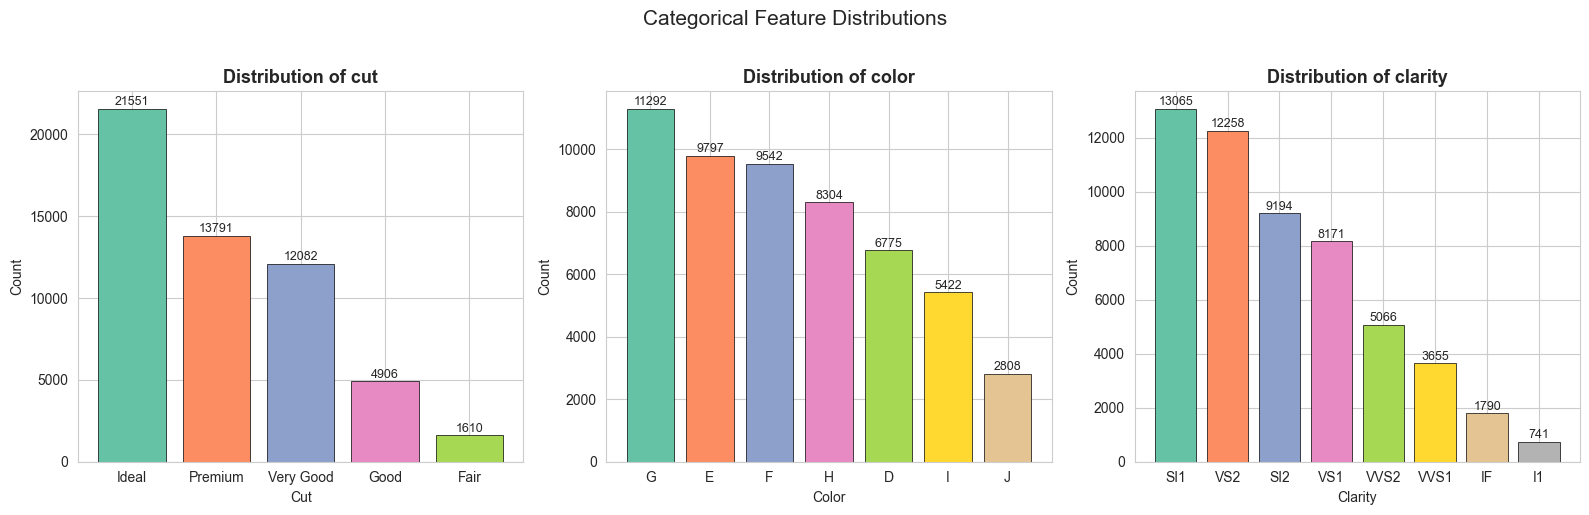

In [5]:
# Step 5: Univariate Analysis — Categorical Features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, categorical_cols):
    counts = df[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('Set2', len(counts)),
           edgecolor='black', linewidth=0.5)
    ax.set_title(f'Distribution of {col}', fontweight='bold', fontsize=13)
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    for i, v in enumerate(counts.values):
        ax.text(i, v + max(counts.values)*0.01, str(v), ha='center', fontsize=9)

plt.suptitle('Categorical Feature Distributions', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

price: Q1=950.0, Q3=5324.2, IQR=4374.2
  Bounds: [-5611.4, 11885.6]
  Outliers: 3540 (6.6%)
carat: Q1=0.4, Q3=1.0, IQR=0.6
  Bounds: [-0.6, 2.0]
  Outliers: 1889 (3.5%)


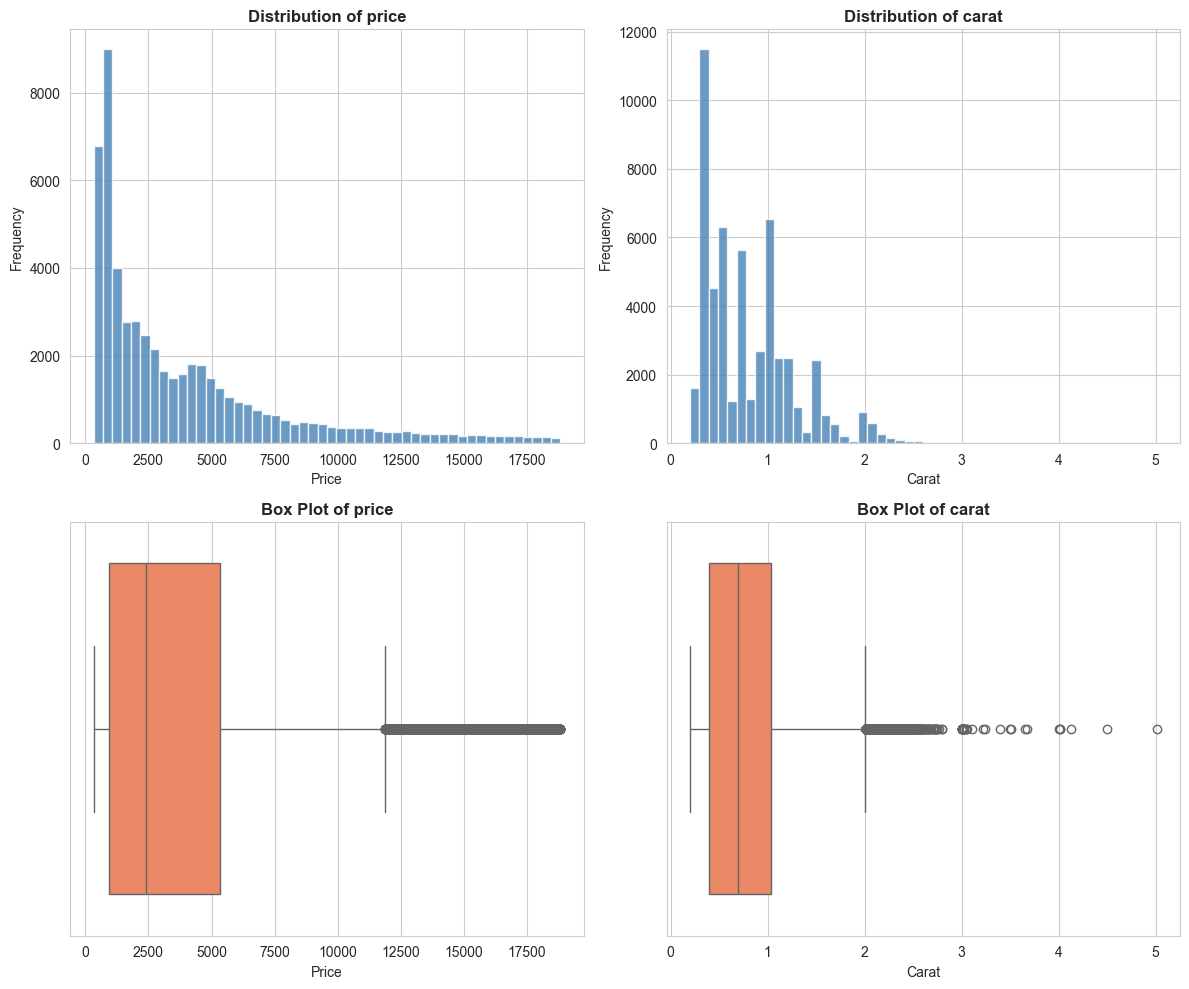

In [6]:
# Step 6: Outlier Detection — IQR Method on Price and Carat
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, col in enumerate(['price', 'carat']):
    # Histogram
    axes[0, i].hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribution of {col}', fontweight='bold')
    axes[0, i].set_xlabel(col.capitalize())
    axes[0, i].set_ylabel('Frequency')

    # Box plot
    sns.boxplot(x=df[col], ax=axes[1, i], color='coral')
    axes[1, i].set_title(f'Box Plot of {col}', fontweight='bold')
    axes[1, i].set_xlabel(col.capitalize())

    # IQR stats
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
    print(f'  Bounds: [{lower:.1f}, {upper:.1f}]')
    print(f'  Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)')

plt.tight_layout()
plt.show()

C:\Users\praka\AppData\Local\Temp\ipykernel_40116\2861083540.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cut', y='price', ax=axes[1, 0], palette='Set2')
C:\Users\praka\AppData\Local\Temp\ipykernel_40116\2861083540.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='color', y='price', ax=axes[1, 1], palette='Set2')


C:\Users\praka\AppData\Local\Temp\ipykernel_40116\2861083540.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clarity', y='price', ax=axes[1, 2], palette='Set2')


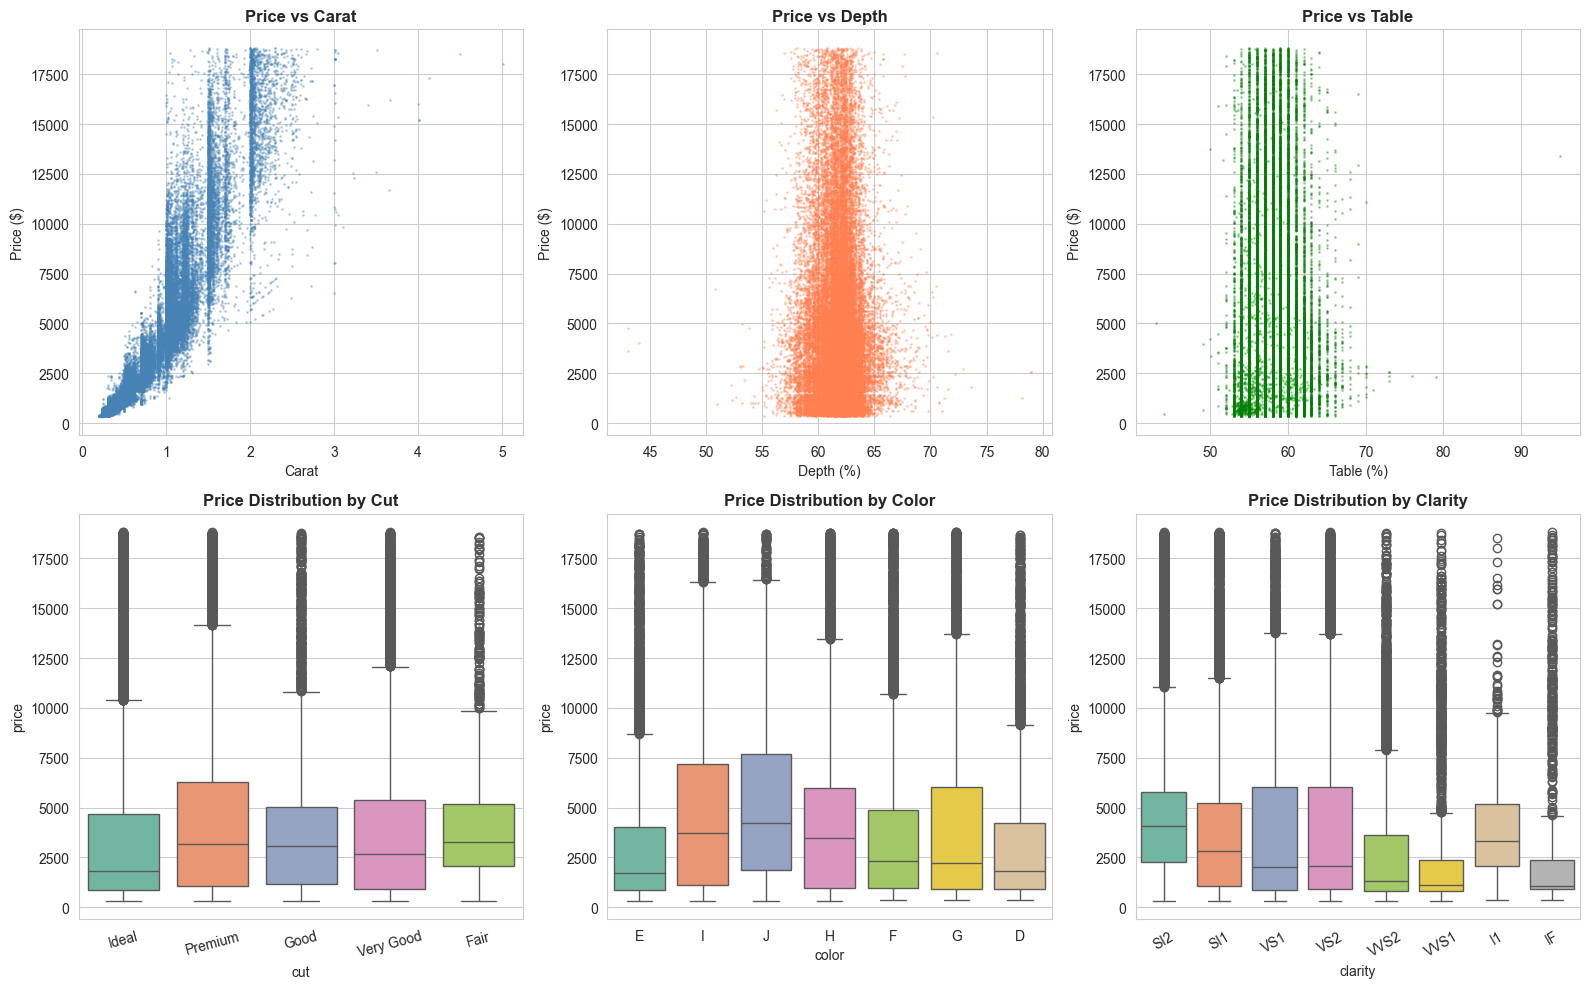

In [7]:
# Step 7: Bivariate Analysis — Price vs Key Features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Price vs Carat
axes[0, 0].scatter(df['carat'], df['price'], alpha=0.3, s=1, color='steelblue')
axes[0, 0].set_xlabel('Carat')
axes[0, 0].set_ylabel('Price ($)')
axes[0, 0].set_title('Price vs Carat', fontweight='bold')

# Price vs Depth
axes[0, 1].scatter(df['depth'], df['price'], alpha=0.3, s=1, color='coral')
axes[0, 1].set_xlabel('Depth (%)')
axes[0, 1].set_ylabel('Price ($)')
axes[0, 1].set_title('Price vs Depth', fontweight='bold')

# Price vs Table
axes[0, 2].scatter(df['table'], df['price'], alpha=0.3, s=1, color='green')
axes[0, 2].set_xlabel('Table (%)')
axes[0, 2].set_ylabel('Price ($)')
axes[0, 2].set_title('Price vs Table', fontweight='bold')

# Price by Cut
sns.boxplot(data=df, x='cut', y='price', ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Price Distribution by Cut', fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=15)

# Price by Color
sns.boxplot(data=df, x='color', y='price', ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Price Distribution by Color', fontweight='bold')

# Price by Clarity
sns.boxplot(data=df, x='clarity', y='price', ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Price Distribution by Clarity', fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

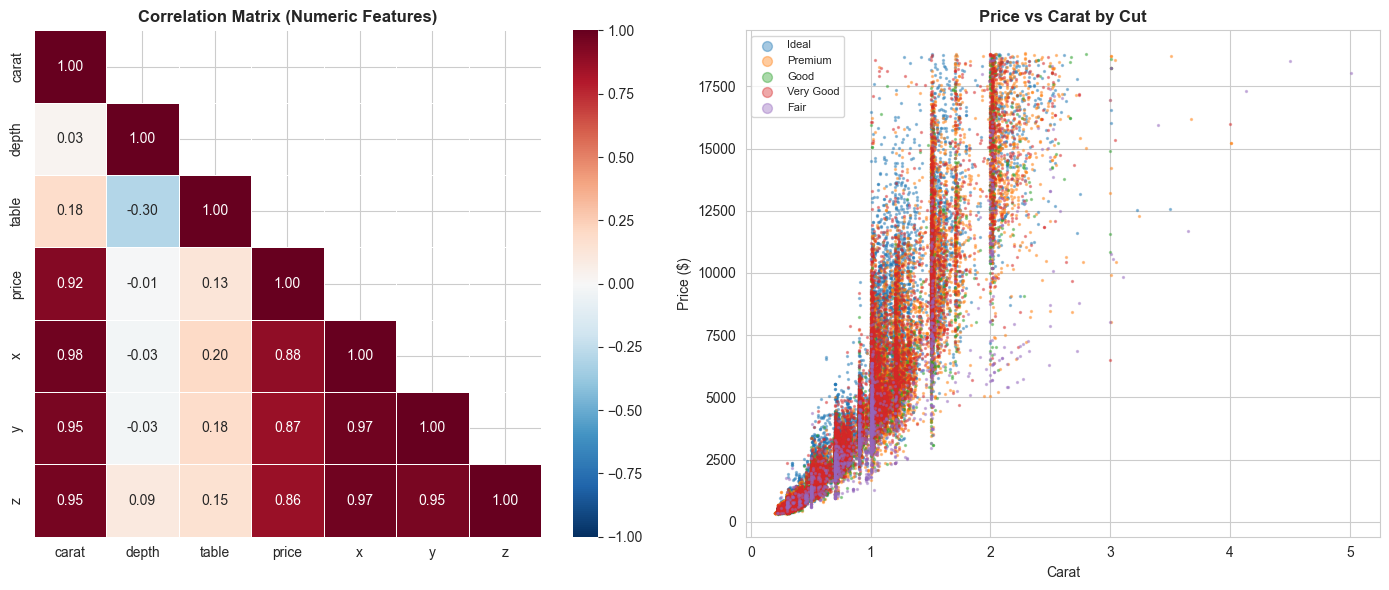

In [8]:
# Step 8: Multivariate Analysis — Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Correlation matrix
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, cmap='RdBu_r', center=0,
           fmt='.2f', linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Correlation Matrix (Numeric Features)', fontweight='bold')

# Price vs Carat colored by Cut
for i, cut in enumerate(df['cut'].unique()):
    subset = df[df['cut'] == cut]
    axes[1].scatter(subset['carat'], subset['price'], alpha=0.4, s=2, label=cut)
axes[1].set_xlabel('Carat')
axes[1].set_ylabel('Price ($)')
axes[1].set_title('Price vs Carat by Cut', fontweight='bold')
axes[1].legend(markerscale=5, fontsize=8)

plt.tight_layout()
plt.show()

C:\Users\praka\AppData\Local\Temp\ipykernel_40116\3712879551.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='cut', y='price', ax=ax1, palette='Set2')
C:\Users\praka\AppData\Local\Temp\ipykernel_40116\3712879551.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='color', y='price', ax=ax2, palette='Set2', inner='quartile')


C:\Users\praka\AppData\Local\Temp\ipykernel_40116\3712879551.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='clarity', y='price', ax=ax3, palette='Set2')


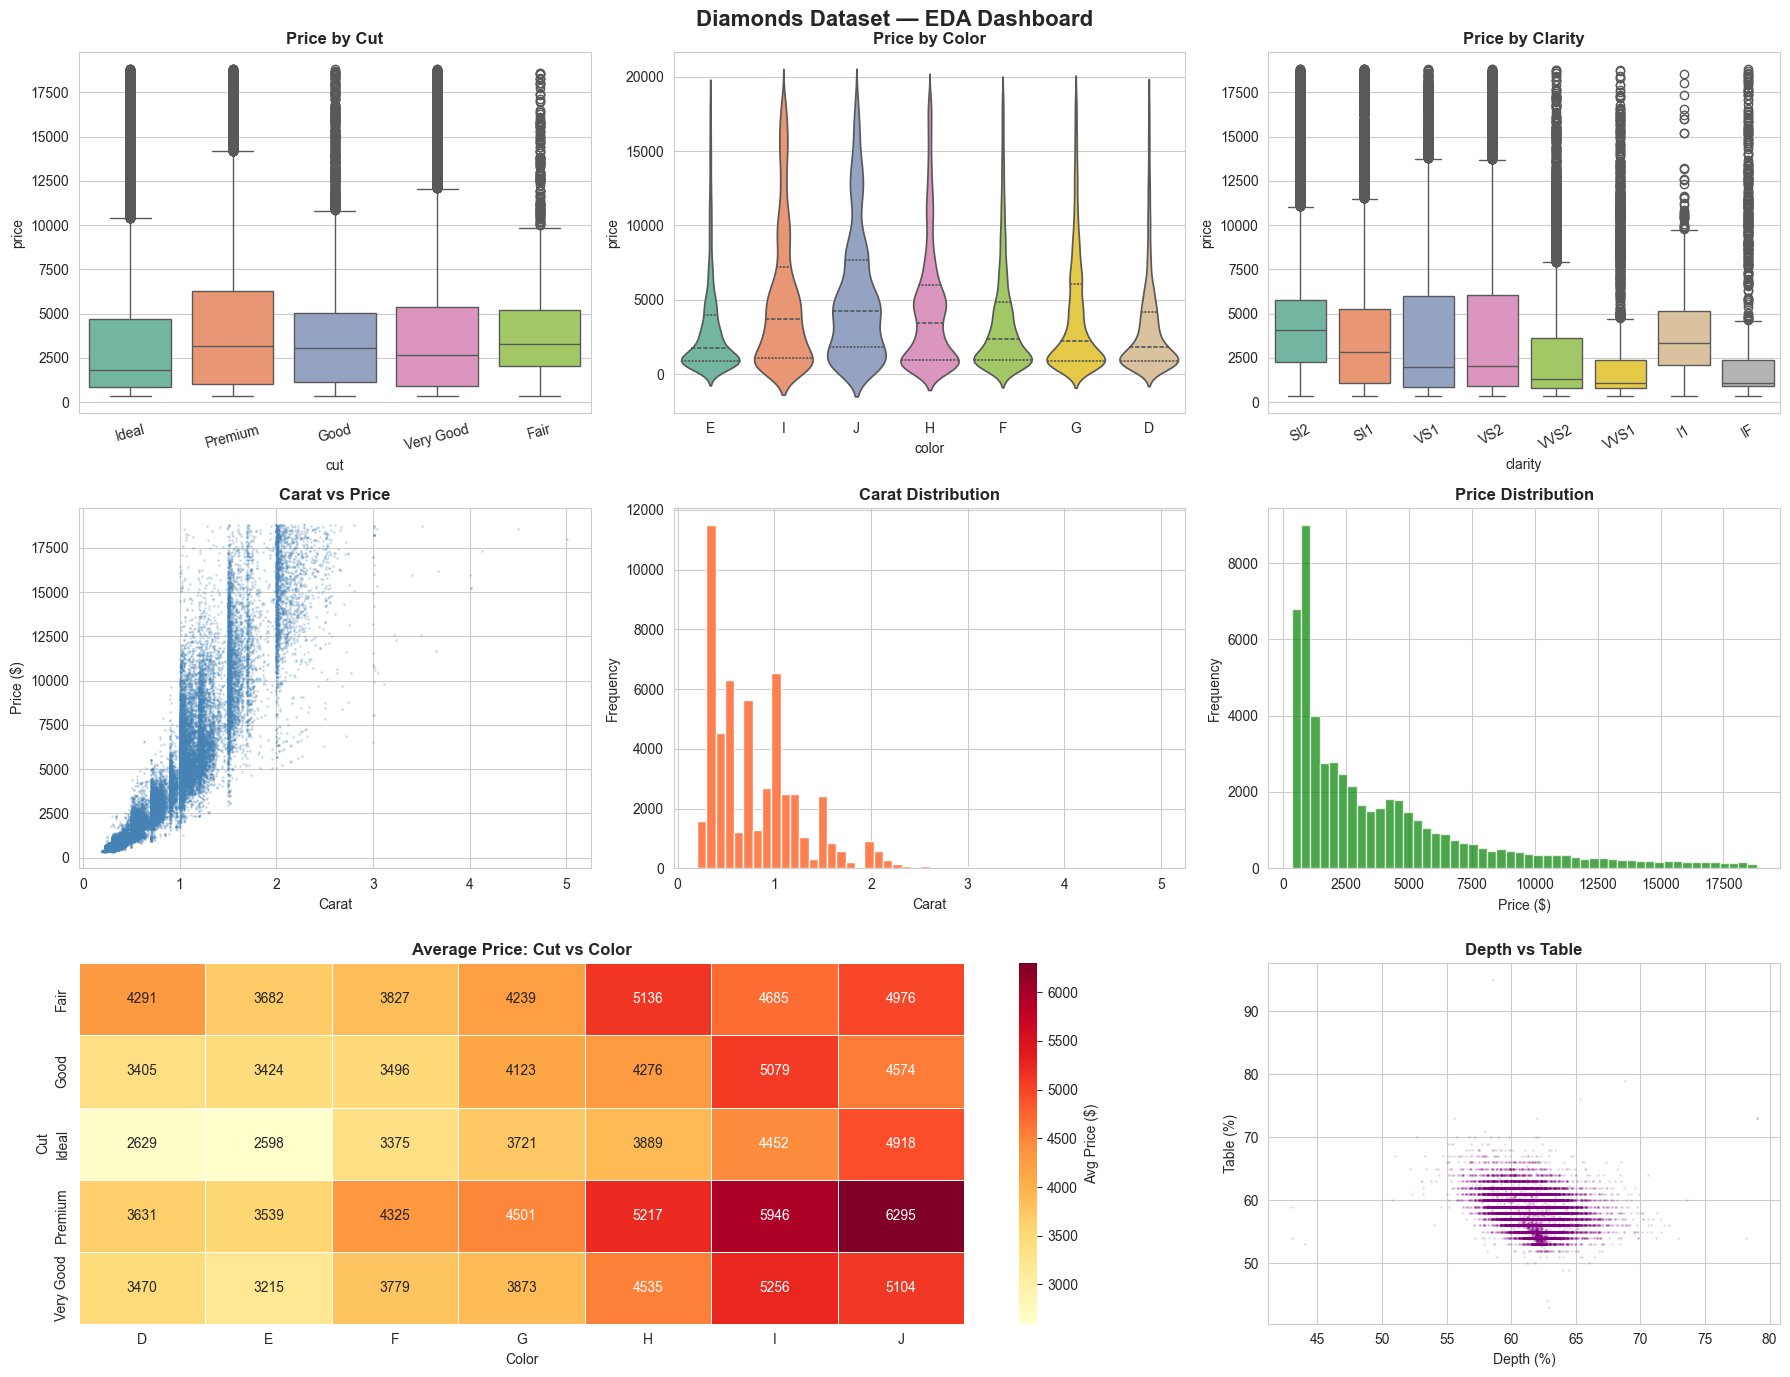

In [9]:
# Step 9: Dashboard-Style Layout — Comprehensive View
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Diamonds Dataset — EDA Dashboard', fontsize=16, fontweight='bold', y=0.98)

# 1. Price distribution by Cut
ax1 = plt.subplot2grid((3, 3), (0, 0))
sns.boxplot(data=df, x='cut', y='price', ax=ax1, palette='Set2')
ax1.set_title('Price by Cut', fontweight='bold')
ax1.tick_params(axis='x', rotation=15)

# 2. Price distribution by Color
ax2 = plt.subplot2grid((3, 3), (0, 1))
sns.violinplot(data=df, x='color', y='price', ax=ax2, palette='Set2', inner='quartile')
ax2.set_title('Price by Color', fontweight='bold')

# 3. Price distribution by Clarity
ax3 = plt.subplot2grid((3, 3), (0, 2))
sns.boxplot(data=df, x='clarity', y='price', ax=ax3, palette='Set2')
ax3.set_title('Price by Clarity', fontweight='bold')
ax3.tick_params(axis='x', rotation=30)

# 4. Carat vs Price scatter
ax4 = plt.subplot2grid((3, 3), (1, 0))
ax4.scatter(df['carat'], df['price'], alpha=0.2, s=1, c='steelblue')
ax4.set_xlabel('Carat')
ax4.set_ylabel('Price ($)')
ax4.set_title('Carat vs Price', fontweight='bold')

# 5. Carat distribution
ax5 = plt.subplot2grid((3, 3), (1, 1))
ax5.hist(df['carat'], bins=50, color='coral', edgecolor='white')
ax5.set_xlabel('Carat')
ax5.set_ylabel('Frequency')
ax5.set_title('Carat Distribution', fontweight='bold')

# 6. Price distribution
ax6 = plt.subplot2grid((3, 3), (1, 2))
ax6.hist(df['price'], bins=50, color='green', edgecolor='white', alpha=0.7)
ax6.set_xlabel('Price ($)')
ax6.set_ylabel('Frequency')
ax6.set_title('Price Distribution', fontweight='bold')

# 7. Average Price by Cut and Color (heatmap)
ax7 = plt.subplot2grid((3, 3), (2, 0), colspan=2)
pivot = df.pivot_table(values='price', index='cut', columns='color', aggfunc='mean')
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax7,
           linewidths=0.5, cbar_kws={'label': 'Avg Price ($)'})
ax7.set_title('Average Price: Cut vs Color', fontweight='bold')
ax7.set_xlabel('Color')
ax7.set_ylabel('Cut')

# 8. Depth vs Table scatter
ax8 = plt.subplot2grid((3, 3), (2, 2))
ax8.scatter(df['depth'], df['table'], alpha=0.1, s=1, c='purple')
ax8.set_xlabel('Depth (%)')
ax8.set_ylabel('Table (%)')
ax8.set_title('Depth vs Table', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
# Step 10: Key Insights and Recommendations
print('=' * 60)
print('KEY INSIGHTS FROM EDA ON DIAMONDS DATASET')
print('=' * 60)
print()
print('1. CARAT IS THE STRONGEST PRICE PREDICTOR')
print('   - Correlation between carat and price: {:.3f}'.format(df['carat'].corr(df['price'])))
print('   - Price increases non-linearly with carat size')
print()
print('2. CUT QUALITY PARADOX')
print('   - Ideal cut diamonds have lower median price than Fair cut')
print('   - Reason: Ideal cuts tend to be smaller (lower carat)')
print('   - When controlling for carat, better cuts do command premium')
print()
print('3. COLOR AND CLARITY IMPACT')
print('   - Best color (D) and clarity (IF) diamonds are rare')
print('   - Price spreads widen significantly for better grades')
print()
print('4. PHYSICAL DIMENSIONS')
print('   - x, y, z dimensions are highly correlated with carat')
print('   - Depth and table show weak correlation with price')
print()
print('5. OUTLIERS')
print('   - Price has significant positive skew (many extreme values)')
print('   - Carat distribution is also right-skewed')
print('   - Some diamonds have physically implausible dimensions')

KEY INSIGHTS FROM EDA ON DIAMONDS DATASET

1. CARAT IS THE STRONGEST PRICE PREDICTOR
   - Correlation between carat and price: 0.922
   - Price increases non-linearly with carat size

2. CUT QUALITY PARADOX
   - Ideal cut diamonds have lower median price than Fair cut
   - Reason: Ideal cuts tend to be smaller (lower carat)
   - When controlling for carat, better cuts do command premium

3. COLOR AND CLARITY IMPACT
   - Best color (D) and clarity (IF) diamonds are rare
   - Price spreads widen significantly for better grades

4. PHYSICAL DIMENSIONS
   - x, y, z dimensions are highly correlated with carat
   - Depth and table show weak correlation with price

5. OUTLIERS
   - Price has significant positive skew (many extreme values)
   - Carat distribution is also right-skewed
   - Some diamonds have physically implausible dimensions


## Dataset Description

- **Dataset:** Diamonds (seaborn built-in, from datasets/diamonds.csv)
- **Records:** 53,940 diamonds
- **Numeric Features:** carat, depth, table, price, x, y, z
- **Categorical Features:** cut (5 levels), color (7 levels), clarity (8 levels)
- **Target (for modeling):** price

## Conclusion

Comprehensive EDA performed on the diamonds dataset. Univariate analysis revealed right-skewed distributions for price and carat with significant outliers. Bivariate analysis showed carat as the dominant price predictor with non-linear relationship. Multivariate analysis using color-coded scatter plots and faceted visualizations revealed interactions between cut, color, and clarity. The dashboard layout provides an integrated view of all key findings. This EDA informs feature engineering and model selection for predicting diamond prices.